In [ ]:
from collections import Counter

import torch

import altair as alt
from scipy.stats import pearsonr

import os
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy.stats import chi2_contingency
import tqdm
from statsmodels.stats.contingency_tables import mcnemar

from natsort import natsorted
import logomaker

from netam import framework
from dnsmex import dxsm_data, dnsm_zoo
from dnsmex.dnsm_oe import write_sites_oe
from dnsmex.local import localify


from netam.common import heavy_chain_shim
from netam.framework import load_crepe, load_pcp_df
from netam.sequences import translate_sequence, AA_STR_SORTED

from dnsmex.dasm_viz import dms_style_heatmap
from dnsmex.local import localify
from dnsmex.dxsm_data import pcp_df_of_nickname

figures_dir = localify("FIGURES_DIR")

## Prep data - Rodriguez dataset

In [2]:
%%bash
## get counts of V and J genes
zcat /fh/fast/matsen_e/shared/bcr-mut-sel/pcps/v1/rodriguez-airr-seq-race-prod-InclMutInv_pcp_2024-11-12_MASKED_NI_noN_no-naive_addJ.csv.gz | tail -n +2 | cut -d ',' -f 11 | cut -d '-' -f 1 | sort | uniq -c | sort -nr
echo "---"
zcat /fh/fast/matsen_e/shared/bcr-mut-sel/pcps/v1/rodriguez-airr-seq-race-prod-InclMutInv_pcp_2024-11-12_MASKED_NI_noN_no-naive_addJ.csv.gz | tail -n +2 | cut -d ',' -f 20 | cut -d '*' -f 1 | sort | uniq -c | sort -nr

   9985 IGHV3
   5246 IGHV4
   4328 IGHV1
    944 IGHV5
    771 IGHV2
    351 IGHV6
    129 IGHV7
---
  11562 IGHJ4
   3563 IGHJ6
   2863 IGHJ5
   2825 IGHJ3
    562 IGHJ2
    379 IGHJ1


In [3]:
dataset_name = "v1rodriguez"
model_name = "dnsm_1m-v1jaffe+v1tang-joint"

crepe_prefix = localify(f"DNSM_TRAINED_MODELS_DIR/{model_name}")
test_output_prefix = localify(f"DNSM_TEST_OUTPUT_DIR/{model_name}-ON-{dataset_name}")

try:
    site_sub_probs_df = pd.read_csv(f"{test_output_prefix}-site_sub_probs_df.csv")
    pcp_df = pd.read_csv(f"{test_output_prefix}-pcp_df.csv")


except FileNotFoundError:
    if not os.path.exists(f"{test_output_prefix}.branch_lengths_csv"):
        dnsm_zoo.write_branch_lengths("/fh/fast/matsen_e/shared/bcr-mut-sel/dnsm/dnsm-experiments-1/dnsm-train/trained_models/dnsm_1m-v1jaffe+v1tang-joint", dataset_name, f"{test_output_prefix}.branch_lengths_csv")


    complete_plotter, plotter_dict = write_sites_oe(
        crepe_prefix=crepe_prefix,
        dataset_name=dataset_name,
        branch_length_path=f"{test_output_prefix}.branch_lengths_csv",
        csv_output_path=f"{test_output_prefix}-sites-oe.csv",
        fig_out_path=f"{figures_dir}/sites-oe-V1,3,4.svg",
        min_log_prob=-4,
        #v_families=["IGHV1", "IGHV2", "IGHV3", "IGHV4", "IGHV5", "IGHV6", "IGHV7"],
        replace_title=True,
    )
    complete_plotter = complete_plotter["heavy"]


    pcp_df = complete_plotter.pcp_df.copy()
    site_sub_probs_df = complete_plotter.site_sub_probs_df.copy()
    for column_name in ['selection_factor', 'neutral_prob', 'prob']:
        site_sub_probs_df[column_name] = site_sub_probs_df[column_name].apply(lambda x: x.item() if hasattr(x, 'item') else x)


    pcp_df.to_csv(f"{test_output_prefix}-pcp_df.csv", index=False)
    site_sub_probs_df.to_csv(f"{test_output_prefix}-site_sub_probs_df.csv", index=False)



    def site_sub_probs_df_without_low_freq(in_plotter, quantile_cutoff=0.05):
        site_sub_probs_df = in_plotter.site_sub_probs_df.copy()
        site_counts = site_sub_probs_df["site"].value_counts()
        cutoff = site_counts.quantile(quantile_cutoff)
        sites_above_cutoff = set(site_counts[site_counts > cutoff].index)
        site_sub_probs_df = site_sub_probs_df[site_sub_probs_df["site"].isin(sites_above_cutoff)]
        return site_sub_probs_df

    def sort_df_by_site(df):
        sorted_index = natsorted(df.index, key=lambda x: df.loc[x, 'site'])
        return df.iloc[sorted_index]

    def build_persite_df(site_sub_probs_df):
        persite_df = site_sub_probs_df.groupby(['site', 'is_cdr']).agg(
            mean_prob=('prob', 'mean'),
            mean_neutral_prob=('neutral_prob', 'mean'),
            mean_selection_factor=('selection_factor', 'mean'),
            mut_freq=('mutation', 'mean')
        ).reset_index()

        persite_df = sort_df_by_site(persite_df)

        return persite_df



In [4]:
# add family annotations to aa and site substitution dfs
pcp_df['j_family'] = pcp_df['j_gene'].str.split('*').str[0]
pcp_df_for_merge = pcp_df.copy()
pcp_df_for_merge = pcp_df_for_merge[['v_gene', 'j_gene', 'v_family', 'j_family', 'sample_id', 'family', 'distance']]
pcp_df_for_merge['pcp_index'] = pcp_df_for_merge.index

site_sub_probs_df = pd.merge(site_sub_probs_df, pcp_df_for_merge, on='pcp_index', how='inner')

site_sub_probs_df['log_selection_factor'] = np.log(site_sub_probs_df['selection_factor'])


<Axes: xlabel='site', ylabel='Count'>

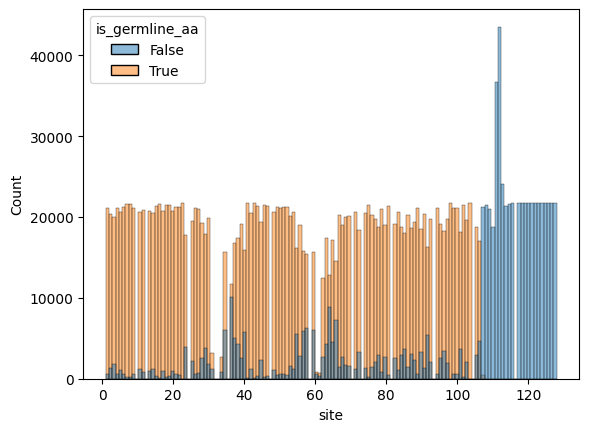

In [5]:
## add germline information
germline_codons_df = pd.read_csv(localify(f"DATA_DIR/germline_codons.csv"))
codon_similarity = pd.read_csv(localify(f"DATA_DIR/germline_codon_similarity.csv"))
aa_similarity = pd.read_csv(localify(f"DATA_DIR/germline_aa_similarity.csv"))
aa_similarity.set_index('v_gene', inplace=True)
codon_similarity.set_index('v_gene', inplace=True)





germline_codons_df['site'] = germline_codons_df['site'].astype(float)

site_sub_probs_df_germline = pd.merge(site_sub_probs_df, germline_codons_df.rename(columns={'codon':'germline_codon', 'amino_acid':'germline_amino_acid'}).drop(columns=['v_family']), on=['v_gene', 'site'], how='left')

site_sub_probs_df_germline['is_germline_aa'] = site_sub_probs_df_germline.parent_aa == site_sub_probs_df_germline.germline_amino_acid
site_sub_probs_df_germline['is_germline_codon'] = site_sub_probs_df_germline.parent_codon == site_sub_probs_df_germline.germline_codon
sns.histplot(site_sub_probs_df_germline, x='site', hue='is_germline_aa')

In [6]:
site_sub_probs_df_germline

,neutral_prob,selection_factor,prob,mutation,pcp_index,site,is_cdr,parent_codon,parent_aa,child_codon,...,v_family,j_family,sample_id,family,distance,log_selection_factor,germline_codon,germline_amino_acid,is_germline_aa,is_germline_codon
0,0.102066,0.132334,0.013507,False,0,1.0,False,CAG,Q,CAG,...,IGHV7,IGHJ4,sample-igg-SC-24,1401,0.096444,-2.022430,CAG,Q,True,True
1,0.030019,0.132334,0.003972,False,1,1.0,False,CAG,Q,CAG,...,IGHV7,IGHJ4,sample-igg-SC-24,1401,0.031971,-2.022430,CAG,Q,True,True
2,0.011072,0.229902,0.002546,False,2,1.0,False,CAG,Q,CAG,...,IGHV4,IGHJ4,sample-igg-SC-24,474,0.079722,-1.470103,CAG,Q,True,True
3,0.054606,0.262477,0.014333,False,3,1.0,False,CAG,Q,CAG,...,IGHV4,IGHJ6,sample-igg-SC-24,238,0.094379,-1.337593,CAG,Q,True,True
4,0.010781,0.262477,0.002830,False,4,1.0,False,CAG,Q,CAG,...,IGHV4,IGHJ6,sample-igg-SC-24,238,0.069703,-1.337593,CAG,Q,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2646366,0.001440,1.122413,0.001617,False,21747,128.0,False,TCA,S,TCA,...,IGHV1,IGHJ1,sample-igg-W-109,62,0.039758,0.115481,NaN,NaN,False,False
2646367,0.001785,1.077277,0.001923,False,21748,128.0,False,TCA,S,TCA,...,IGHV3,IGHJ5,sample-igg-W-109,10,0.109737,0.074437,NaN,NaN,False,False
2646368,0.001744,1.077277,0.001879,False,21749,128.0,False,TCA,S,TCA,...,IGHV3,IGHJ5,sample-igg-W-109,10,0.112585,0.074437,NaN,NaN,False,False
2646369,0.001797,1.249783,0.002246,False,21750,128.0,False,TCA,S,TCA,...,IGHV1,IGHJ4,sample-igg-W-117,10,0.119753,0.222970,NaN,NaN,False,False


In [7]:
def is_parent_child_one_mutation_away(parent_codon, child_codon):
    """
    Check if two codons are one mutation away from each other.
    """
    if parent_codon == child_codon:
        return False
    # Check if they differ by exactly one nucleotide mutation
    mutations = sum(1 for p, c in zip(parent_codon, child_codon) if p != c)
    return mutations == 1

site_sub_probs_df_germline['is_one_mutation_away'] = site_sub_probs_df_germline.apply(
    lambda row: is_parent_child_one_mutation_away(row['parent_codon'], row['child_codon']),
    axis=1
)

In [8]:
site_sub_probs_df_germline.groupby(['mutation', 'is_one_mutation_away']).size().reset_index()


,mutation,is_one_mutation_away,0
0,False,False,2450908
1,False,True,72290
2,True,False,22033
3,True,True,101140


## association analysis

In [55]:
def calculate_association_between_sites(site_sub_probs_df, site1, site2):
    """
    Calculate the association between two sites based on their mutation probabilities.

    Simplest function - doesn't matter what the parent or child is, only aggregating over an occurence of a mutaiton at each site.
    """
    cfs_with_site1_mutation = site_sub_probs_df[(site_sub_probs_df['site'] == site1) & (site_sub_probs_df_germline.mutation == True)][['family', 'sample_id']].drop_duplicates()
    cfs_with_site2_mutation = site_sub_probs_df[(site_sub_probs_df['site'] == site2) & (site_sub_probs_df_germline.mutation == True)][['family', 'sample_id']].drop_duplicates()
    
    cfs_count = len(site_sub_probs_df_germline[['family', 'sample_id']].drop_duplicates())

    cfs_with_both_mutations = len(pd.merge(cfs_with_site1_mutation, cfs_with_site2_mutation, on=['family', 'sample_id'], how='inner'))
    cfs_with_site1_mutation_only = len(cfs_with_site1_mutation) - cfs_with_both_mutations
    cfs_with_site2_mutation_only = len(cfs_with_site2_mutation) - cfs_with_both_mutations
    cfs_with_neither_mutation = cfs_count - (cfs_with_both_mutations + cfs_with_site1_mutation_only + cfs_with_site2_mutation_only)
    
    contingency_table = np.array([
        [cfs_with_both_mutations, cfs_with_site1_mutation_only],
        [cfs_with_site2_mutation_only, cfs_with_neither_mutation]
    ])  
    # calculate chi-squared statistic with package
    chi2, p_value, dof, expected_freq = chi2_contingency(contingency_table)

    return contingency_table, chi2, p_value

    


In [56]:
calculate_association_between_sites(site_sub_probs_df_germline, 30,50)

(array([[  65,  744],
        [ 264, 6688]]),
 np.float64(31.014164852694417),
 np.float64(2.5615218239724437e-08))

In [67]:
results = []
for i in tqdm.tqdm(range(30, 50)):
    for j in range(30, 50):
        if i != j:
            try:
                contingency_table, chi2, p_value = calculate_association_between_sites(site_sub_probs_df_germline, i, j)
                results.append({
                    'site1': i,
                    'site2': j,
                    'contingency_table': contingency_table,
                    'chi2': chi2,
                    'p_value': p_value
                })
            except:
                pass
results_df = pd.DataFrame(results)



100%|██████████| 20/20 [00:50<00:00,  2.50s/it]


In [68]:
# apply FDR correction to p-values
from statsmodels.stats.multitest import multipletests
results_df['fdr_corrected_p_value'] = multipletests(results_df['p_value'], method='fdr_bh')[1]


<Axes: >

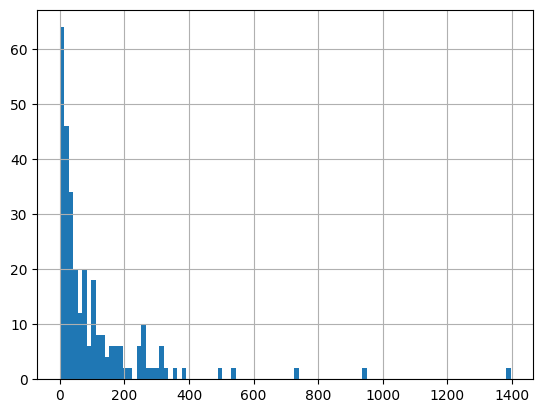

In [69]:
results_df.chi2.hist(bins=100)

<Axes: >

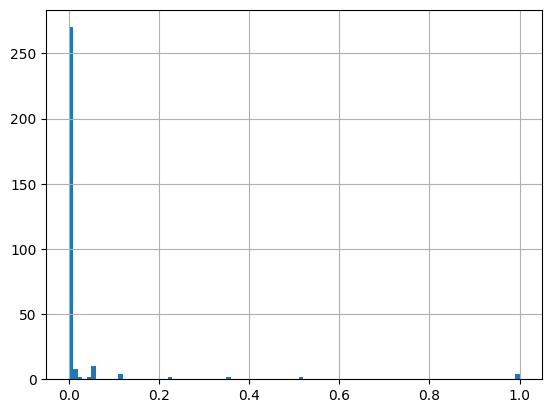

In [70]:
results_df.p_value.hist(bins=100)

<Axes: >

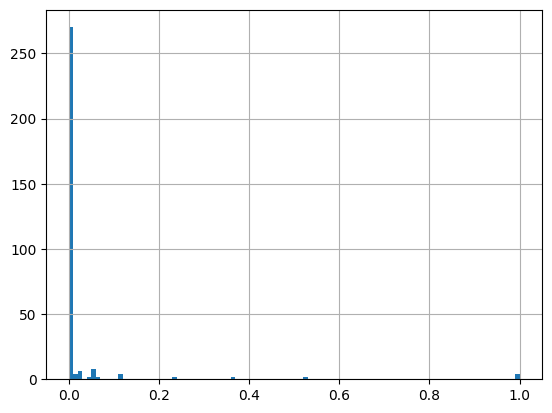

In [71]:
results_df['fdr_corrected_p_value'].hist(bins=100)  

Text(0.5, 1.0, 'Chi2 vs P-value for Site Associations')

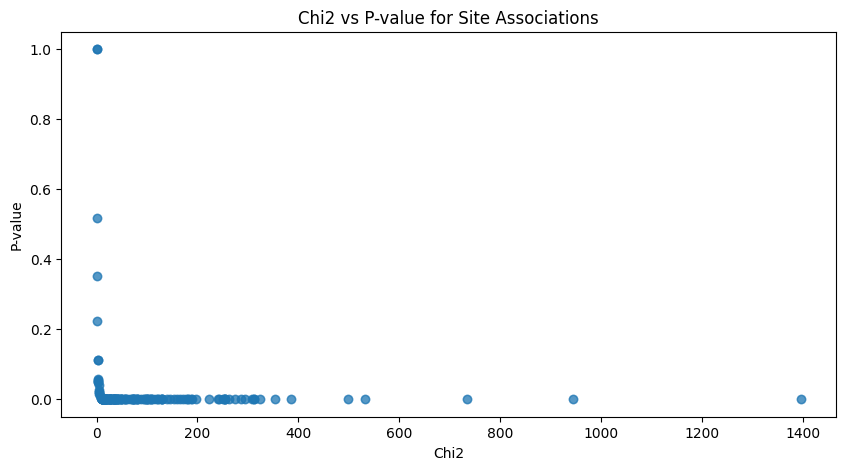

In [74]:
# plot the dostribution of chi2 and p-values pairs

plt.figure(figsize=(10, 5))
plt.scatter(results_df.chi2, results_df.p_value, alpha=0.5)
plt.xlabel('Chi2')
plt.ylabel('P-value')
plt.title('Chi2 vs P-value for Site Associations')

In [75]:
results_df.sort_values(by='chi2', ascending=True, inplace=True)

In [76]:
results_df

,site1,site2,contingency_table,chi2,p_value,fdr_corrected_p_value
27,31,43,"[[1, 440], [25, 7295]]",0.000000,1.000000e+00,1.000000e+00
189,43,34,"[[1, 25], [294, 7441]]",0.000000,1.000000e+00,1.000000e+00
188,43,31,"[[1, 25], [440, 7295]]",0.000000,1.000000e+00,1.000000e+00
44,34,43,"[[1, 294], [25, 7441]]",0.000000,1.000000e+00,1.000000e+00
47,34,46,"[[8, 287], [149, 7317]]",0.417457,5.182084e-01,5.250721e-01
...,...,...,...,...,...,...
72,36,37,"[[876, 1505], [578, 4802]]",733.841822,1.308646e-161,6.674094e-160
71,36,35,"[[1238, 1143], [962, 4418]]",944.007315,2.663236e-207,2.037376e-205
54,35,36,"[[1238, 962], [1143, 4418]]",944.007315,2.663236e-207,2.037376e-205
18,31,34,"[[163, 278], [132, 7188]]",1396.481088,1.222072e-305,1.869770e-303


In [77]:
def calculate_association_between_sites(site_sub_probs_df, site1, site2):
    """
    Calculate the association between two sites based on their mutation probabilities.

    Simplest function - doesn't matter what the parent or child is, only aggregating over an occurence of a mutaiton at each site.
    """
    cfs_with_site1_mutation = site_sub_probs_df[(site_sub_probs_df['site'] == site1) & (site_sub_probs_df_germline.mutation == True)][['family', 'sample_id']].drop_duplicates()
    cfs_with_site2_mutation = site_sub_probs_df[(site_sub_probs_df['site'] == site2) & (site_sub_probs_df_germline.mutation == True)][['family', 'sample_id']].drop_duplicates()
    
    cfs_count = len(site_sub_probs_df_germline[['family', 'sample_id']].drop_duplicates())

    cfs_with_both_mutations = len(pd.merge(cfs_with_site1_mutation, cfs_with_site2_mutation, on=['family', 'sample_id'], how='inner'))
    cfs_with_site1_mutation_only = len(cfs_with_site1_mutation) - cfs_with_both_mutations
    cfs_with_site2_mutation_only = len(cfs_with_site2_mutation) - cfs_with_both_mutations
    cfs_with_neither_mutation = cfs_count - (cfs_with_both_mutations + cfs_with_site1_mutation_only + cfs_with_site2_mutation_only)
    
    contingency_table = np.array([
        [cfs_with_both_mutations, cfs_with_site1_mutation_only],
        [cfs_with_site2_mutation_only, cfs_with_neither_mutation]
    ])  
    
    # calculate chi-squared statistic with package
    chi2, p_value, dof, expected_freq = chi2_contingency(contingency_table)
    
    # Determine association type
    observed_both = cfs_with_both_mutations
    observed_neither = cfs_with_neither_mutation
    observed_site1_only = cfs_with_site1_mutation_only
    observed_site2_only = cfs_with_site2_mutation_only
    
    # Calculate odds ratio to determine association direction
    if observed_site1_only * observed_site2_only == 0:
        # Avoid division by zero
        odds_ratio = float('inf') if observed_both * observed_neither > 0 else 0
    else:
        odds_ratio = (observed_both * observed_neither) / (observed_site1_only * observed_site2_only)
    
    # Determine association type
    if odds_ratio > 1:
        association_type = "positive"  # Co-occurrence
    elif odds_ratio < 1:
        association_type = "negative"  # Mutual exclusion
    else:
        association_type = "independent"
    
    return contingency_table, chi2, p_value, odds_ratio, association_type

In [79]:
table, chi2, p_val, odds_ratio, assoc_type = calculate_association_between_sites(site_sub_probs_df_germline, 30, 50)
print(f"Chi2: {chi2:.3f}, p: {p_val:.3e}, OR: {odds_ratio:.3f}, Type: {assoc_type}")

Chi2: 31.014, p: 2.562e-08, OR: 2.213, Type: positive


In [90]:
results = []
sites = site_sub_probs_df_germline['site'].unique()
for i in tqdm.tqdm(sites):
    for j in sites:
        if i > j:
            try:
                contingency_table, chi2, p_value, odds_ratio, association_type = calculate_association_between_sites(site_sub_probs_df_germline, i, j)
                results.append({
                    'site1': i,
                    'site2': j,
                    'contingency_table': contingency_table,
                    'chi2': chi2,
                    'p_value': p_value,
                    'odds_ratio': odds_ratio,
                    'association_type': association_type

                })
            except:
                pass
results_df = pd.DataFrame(results)



  0%|          | 0/144 [00:00<?, ?it/s]

100%|██████████| 144/144 [22:37<00:00,  9.43s/it]


results_df.to_csv(f"{test_output_prefix}-counts_association_results.csv", index=False)

In [94]:
results_df.association_type.value_counts()

association_type
positive    8529
negative     924
Name: count, dtype: int64

In [82]:
results_df.sort_values(by='association_type')

,site1,site2,contingency_table,chi2,p_value,odds_ratio,association_type
40,34,39,"[[5, 290], [792, 6674]]",23.508986,1.243317e-06,0.145289,negative
23,31,39,"[[7, 434], [790, 6530]]",37.255014,1.036482e-09,0.133320,negative
188,43,31,"[[1, 25], [440, 7295]]",0.000000,1.000000e+00,0.663182,negative
120,39,31,"[[7, 790], [434, 6530]]",37.255014,1.036482e-09,0.133320,negative
121,39,34,"[[5, 792], [290, 6674]]",23.508986,1.243317e-06,0.145289,negative
...,...,...,...,...,...,...,...
100,37,48,"[[298, 1156], [437, 5870]]",252.071455,9.180179e-57,3.462702,positive
99,37,47,"[[90, 1364], [149, 6158]]",56.717516,5.031339e-14,2.726978,positive
98,37,46,"[[56, 1398], [101, 6206]]",29.057378,7.026598e-08,2.461338,positive
96,37,44,"[[91, 1363], [164, 6143]]",48.619676,3.107360e-12,2.500819,positive


In [ ]:
results_df['log_odds_ratio'] = np.log(results_df['odds_ratio'])


/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


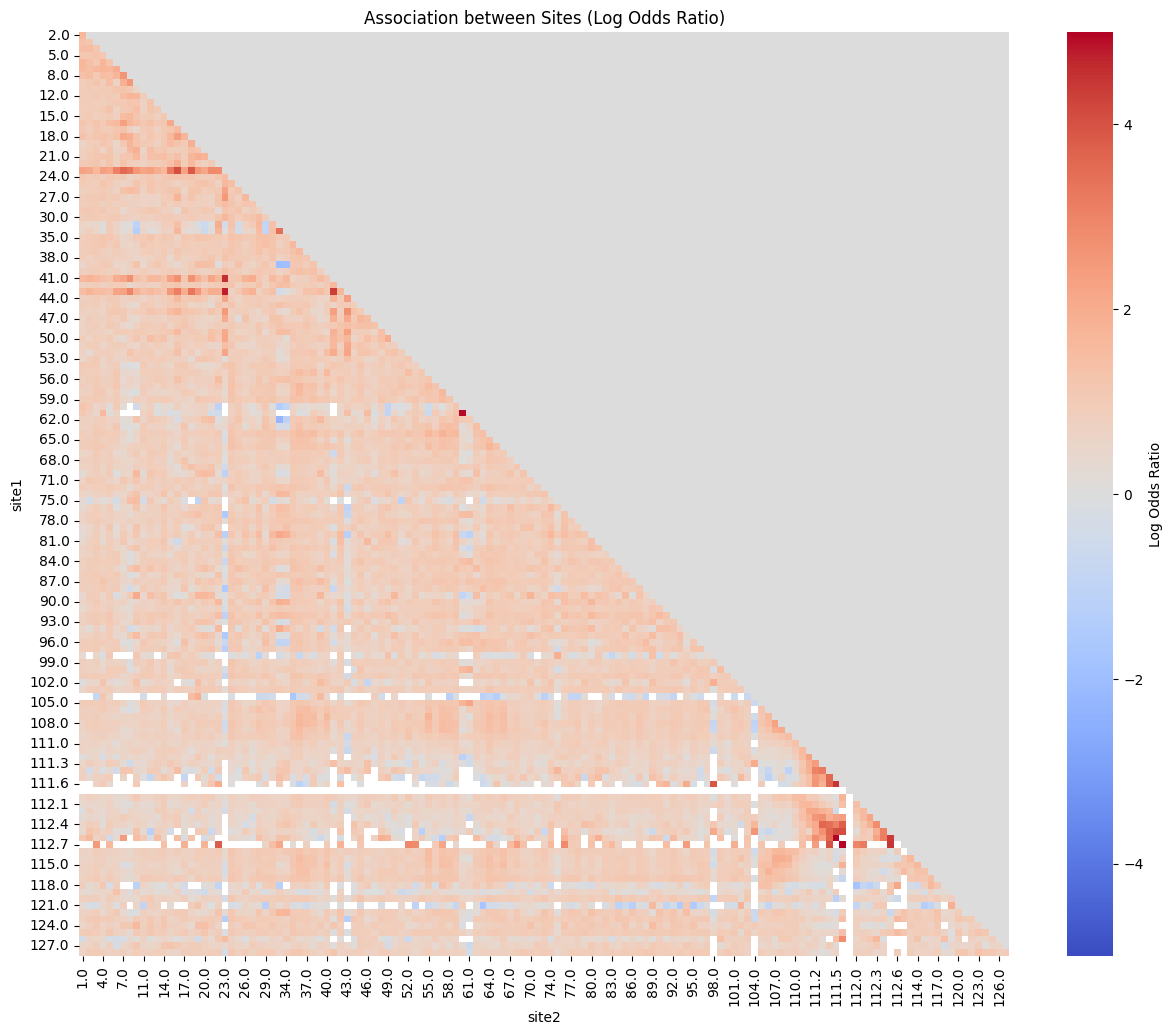

In [ ]:
# plot a heatmap for the association between sites using the log_odds_ratio
heatmap_data = results_df.pivot_table(index='site1', columns='site2', values='log_odds_ratio', fill_value=0)
heatmap_data = heatmap_data.reindex(sorted(heatmap_data.index))
heatmap_data = heatmap_data.astype(float)
fig, ax = plt.subplots(figsize=(15, 12))
sns.heatmap(heatmap_data, cmap='coolwarm',cbar_kws={'label': 'Log Odds Ratio'}, vmin=-5, vmax=5)
plt.title('Association between Sites (Log Odds Ratio)')
plt.show()

In [ ]:
## need to first filter only for pcps where both sites imgt are present
## also - maybe filter for a subset of pcps. maybe a v family? maybe a v gene?
## need to flip the 112,1, 112.4 order etc

## also, maybe remove the germline filter??

In [9]:
def calculate_association_between_sites(site_sub_probs_df_germline, site1, site2):
    """
    Calculate the association between two sites based on their mutation probabilities.

    Simplest function - doesn't matter what the parent or child is, only aggregating over an occurence of a mutaiton at each site.
    """
    cfs_with_both_sites = pd.merge(site_sub_probs_df_germline[(site_sub_probs_df_germline['site'] == site1)][['family', 'sample_id']].drop_duplicates(), site_sub_probs_df_germline[(site_sub_probs_df_germline['site'] == site2)][['family', 'sample_id']].drop_duplicates(), on=['family', 'sample_id'], how='inner')

    cur_df = pd.merge(site_sub_probs_df_germline, cfs_with_both_sites, on=['family', 'sample_id'], how='inner')

    cfs_with_site1_mutation = cur_df[(cur_df['site'] == site1) & (cur_df.mutation == True)][['family', 'sample_id']].drop_duplicates()
    cfs_with_site2_mutation = cur_df[(cur_df['site'] == site2) & (cur_df.mutation == True)][['family', 'sample_id']].drop_duplicates()
    cfs_count = len(cur_df[['family', 'sample_id']].drop_duplicates())

    cfs_with_both_mutations = len(pd.merge(cfs_with_site1_mutation, cfs_with_site2_mutation, on=['family', 'sample_id'], how='inner'))
    cfs_with_site1_mutation_only = len(cfs_with_site1_mutation) - cfs_with_both_mutations
    cfs_with_site2_mutation_only = len(cfs_with_site2_mutation) - cfs_with_both_mutations
    cfs_with_neither_mutation = cfs_count - (cfs_with_both_mutations + cfs_with_site1_mutation_only + cfs_with_site2_mutation_only)
    
    contingency_table = np.array([
        [cfs_with_both_mutations, cfs_with_site1_mutation_only],
        [cfs_with_site2_mutation_only, cfs_with_neither_mutation]
    ])  
    # calculate chi-squared statistic with package
    chi2, p_value, dof, expected_freq = chi2_contingency(contingency_table)
    
    # Determine association type
    observed_both = cfs_with_both_mutations
    observed_neither = cfs_with_neither_mutation
    observed_site1_only = cfs_with_site1_mutation_only
    observed_site2_only = cfs_with_site2_mutation_only
    
    # Calculate odds ratio to determine association direction
    if observed_site1_only * observed_site2_only == 0:
        # Avoid division by zero
        odds_ratio = float('inf') if observed_both * observed_neither > 0 else 0
    else:
        odds_ratio = (observed_both * observed_neither) / (observed_site1_only * observed_site2_only)
    
    # Determine association type
    if odds_ratio > 1:
        association_type = "positive"  # Co-occurrence
    elif odds_ratio < 1:
        association_type = "negative"  # Mutual exclusion
    else:
        association_type = "independent"
    
    return contingency_table, chi2, p_value, odds_ratio, association_type

In [10]:
results = []
site_sub_probs_df_germline_v1 = site_sub_probs_df_germline[site_sub_probs_df_germline['v_family'] == 'IGHV1']
sites = site_sub_probs_df_germline['site'].unique()

for i in tqdm.tqdm(sites):
    for j in sites:
        if i > j:
            try:
                contingency_table, chi2, p_value, odds_ratio, association_type = calculate_association_between_sites(site_sub_probs_df_germline_v1, i, j)
                results.append({
                    'site1': i,
                    'site2': j,
                    'contingency_table': contingency_table,
                    'chi2': chi2,
                    'p_value': p_value,
                    'odds_ratio': odds_ratio,
                    'association_type': association_type

                })
            except:
                pass
results_df = pd.DataFrame(results)
results_df['log_odds_ratio'] = np.log(results_df['odds_ratio'])




 20%|██        | 29/144 [01:10<08:35,  4.48s/it]/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/scipy/stats/contingency.py:135: RuntimeWarning: invalid value encountered in divide
  expected = reduce(np.multiply, margsums) / observed.sum() ** (d - 1)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/scipy/stats/contingency.py:135: RuntimeWarning: invalid value encountered in divide
  expected = reduce(np.multiply, margsums) / observed.sum() ** (d - 1)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/scipy/stats/contingency.py:135: RuntimeWarning: invalid value encountered in divide
  expected = reduce(np.multiply, margsums) / observed.sum() ** (d - 1)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/scipy/stats/contingency.py:135: RuntimeWarning: invalid value encountered in divide
  expected = reduce(np.multiply, margsums) / observed.sum() ** (d - 1)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-p

/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


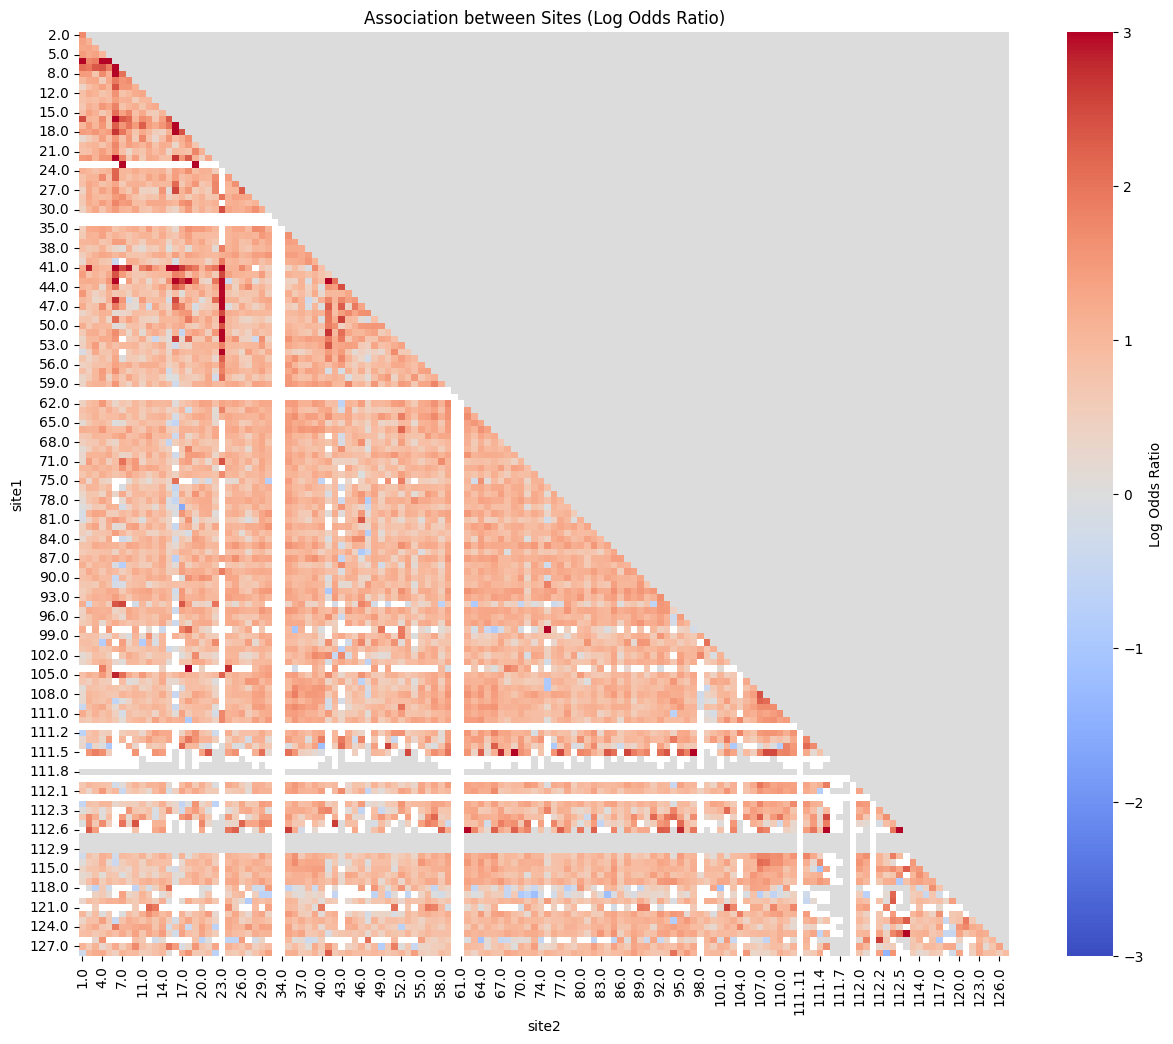

In [ ]:
# plot a heatmap for the association between sites using the log_odds_ratio
heatmap_data = results_df.pivot_table(index='site1', columns='site2', values='log_odds_ratio', fill_value=0)
heatmap_data = heatmap_data.reindex(sorted(heatmap_data.index))
heatmap_data = heatmap_data.astype(float)
fig, ax = plt.subplots(figsize=(15, 12))
sns.heatmap(heatmap_data, cmap='coolwarm',cbar_kws={'label': 'Log Odds Ratio'}, vmin=-3, vmax=3)
plt.title('Association between Sites (Log Odds Ratio)')
plt.show()

In [12]:
results_df.to_csv(f"{test_output_prefix}-counts_association_results_ighv1.csv", index=False)

In [27]:
results_df

,site1,site2,contingency_table,chi2,p_value,odds_ratio,association_type,log_odds_ratio
0,2.0,1.0,"[[22, 122], [46, 1411]]",44.404748,2.670386e-11,5.531361,positive,1.710434
1,3.0,1.0,"[[27, 226], [41, 1307]]",28.648779,8.676870e-08,3.808439,positive,1.337220
2,3.0,2.0,"[[48, 205], [96, 1252]]",35.114716,3.108429e-09,3.053659,positive,1.116340
3,4.0,1.0,"[[10, 70], [58, 1463]]",12.046635,5.188597e-04,3.603448,positive,1.281891
4,4.0,2.0,"[[20, 60], [124, 1397]]",24.336633,8.088608e-07,3.755376,positive,1.323189
...,...,...,...,...,...,...,...,...
9574,128.0,123.0,"[[30, 64], [179, 1328]]",29.557211,5.429030e-08,3.477654,positive,1.246358
9575,128.0,124.0,"[[11, 83], [78, 1429]]",5.989028,1.439514e-02,2.428020,positive,0.887076
9576,128.0,125.0,"[[25, 69], [195, 1312]]",12.792756,3.479641e-04,2.437755,positive,0.891078
9577,128.0,126.0,"[[1, 93], [9, 1498]]",0.000000,1.000000e+00,1.789725,positive,0.582062


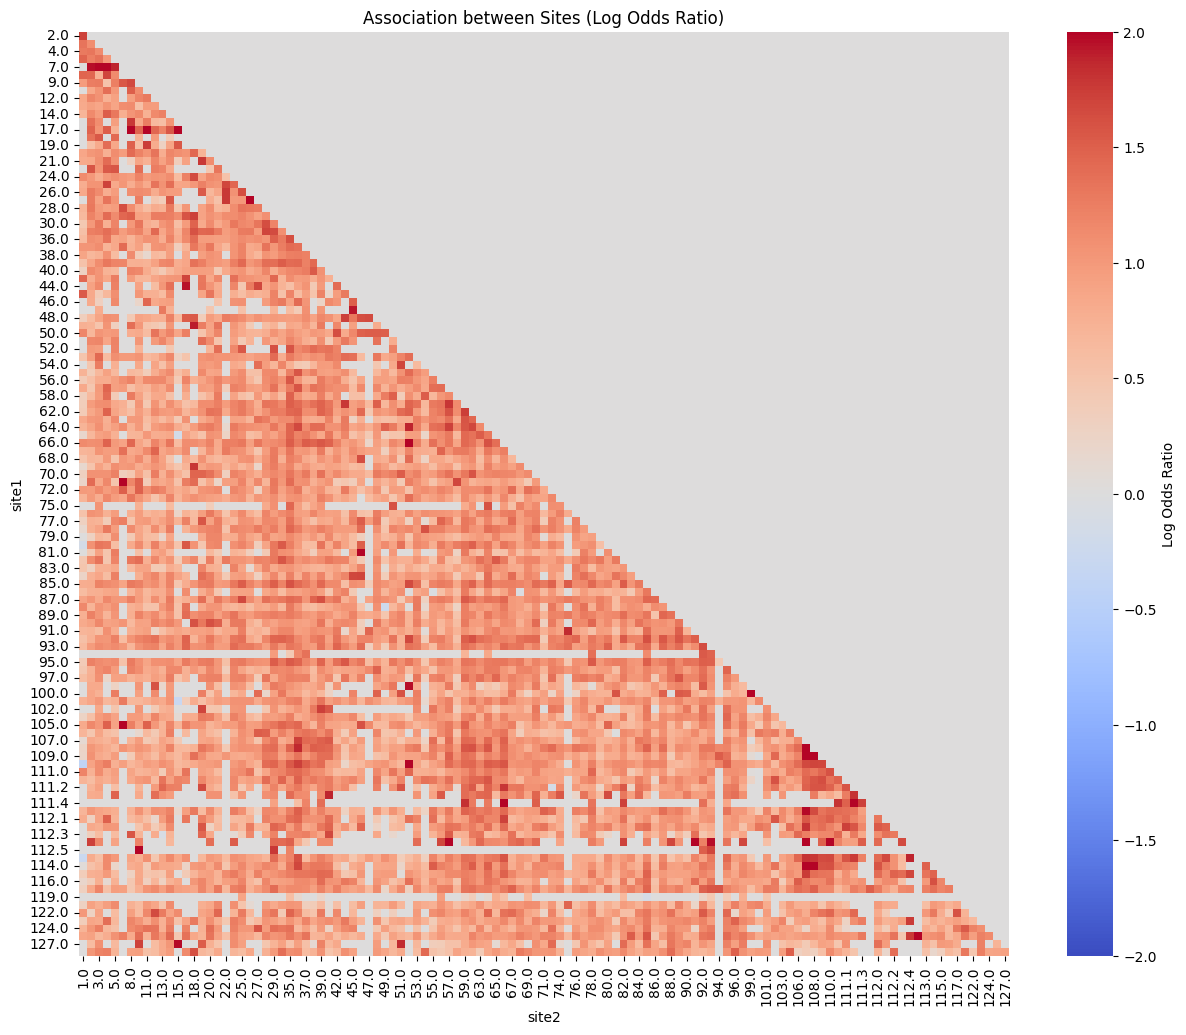

In [35]:
# filter results df for rows where both mutations have been seen more then 10 times according to the contingency table
results_df_filtered = results_df[(results_df['contingency_table'].apply(lambda x: x[0, 0]) > 5) & (results_df['contingency_table'].apply(lambda x: x[1, 1]) > 5) & (results_df['contingency_table'].apply(lambda x: x[0, 1]) > 5) & (results_df['contingency_table'].apply(lambda x: x[1, 0]) > 5)]


# plot a heatmap for the association between sites using the log_odds_ratio
heatmap_data = results_df_filtered.pivot_table(index='site1', columns='site2', values='log_odds_ratio', fill_value=0)
heatmap_data = heatmap_data.reindex(sorted(heatmap_data.index))
heatmap_data = heatmap_data.astype(float)
fig, ax = plt.subplots(figsize=(15, 12))
sns.heatmap(heatmap_data, cmap='coolwarm',cbar_kws={'label': 'Log Odds Ratio'}, vmin=-2, vmax=2)
plt.title('Association between Sites (Log Odds Ratio)')
plt.show()

In [15]:
site_sub_probs_df_germline_v1

,neutral_prob,selection_factor,prob,mutation,pcp_index,site,is_cdr,parent_codon,parent_aa,child_codon,...,v_family,j_family,sample_id,family,log_selection_factor,germline_codon,germline_amino_acid,is_germline_aa,is_germline_codon,is_one_mutation_away
52,0.017692,0.126629,0.002240,False,52,1.0,False,CAG,Q,CAG,...,IGHV1,IGHJ4,sample-igg-SC-24,995,-2.066490,CAG,Q,True,True,False
53,0.178223,0.129744,0.023123,False,53,1.0,False,CAG,Q,CAA,...,IGHV1,IGHJ4,sample-igg-SC-24,995,-2.042195,CAG,Q,True,True,True
54,0.204427,0.129744,0.026523,False,54,1.0,False,CAG,Q,CAG,...,IGHV1,IGHJ4,sample-igg-SC-24,995,-2.042195,CAG,Q,True,True,False
55,0.251854,0.126629,0.031892,False,55,1.0,False,CAG,Q,CAG,...,IGHV1,IGHJ4,sample-igg-SC-24,995,-2.066490,CAG,Q,True,True,False
64,0.082727,0.118290,0.009786,True,64,1.0,False,CAG,Q,CGG,...,IGHV1,IGHJ4,sample-igg-SC-24,141,-2.134616,CAG,Q,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2646349,0.002358,0.589386,0.001390,False,21730,128.0,False,TCA,S,TCA,...,IGHV1,IGHJ4,sample-igg-W-92,82,-0.528674,NaN,NaN,False,False,False
2646363,0.014877,1.087926,0.016185,False,21744,128.0,False,TCA,S,TCA,...,IGHV1,IGHJ6,sample-igg-W-1,186,0.084273,NaN,NaN,False,False,False
2646364,0.013142,1.087926,0.014297,False,21745,128.0,False,TCA,S,TCA,...,IGHV1,IGHJ6,sample-igg-W-1,186,0.084273,NaN,NaN,False,False,False
2646366,0.001440,1.122413,0.001617,False,21747,128.0,False,TCA,S,TCA,...,IGHV1,IGHJ1,sample-igg-W-109,62,0.115481,NaN,NaN,False,False,False


In [16]:
site_sub_probs_df_germline

,neutral_prob,selection_factor,prob,mutation,pcp_index,site,is_cdr,parent_codon,parent_aa,child_codon,...,v_family,j_family,sample_id,family,log_selection_factor,germline_codon,germline_amino_acid,is_germline_aa,is_germline_codon,is_one_mutation_away
0,0.102066,0.132334,0.013507,False,0,1.0,False,CAG,Q,CAG,...,IGHV7,IGHJ4,sample-igg-SC-24,1401,-2.022430,CAG,Q,True,True,False
1,0.030019,0.132334,0.003972,False,1,1.0,False,CAG,Q,CAG,...,IGHV7,IGHJ4,sample-igg-SC-24,1401,-2.022430,CAG,Q,True,True,False
2,0.011072,0.229902,0.002546,False,2,1.0,False,CAG,Q,CAG,...,IGHV4,IGHJ4,sample-igg-SC-24,474,-1.470103,CAG,Q,True,True,False
3,0.054606,0.262477,0.014333,False,3,1.0,False,CAG,Q,CAG,...,IGHV4,IGHJ6,sample-igg-SC-24,238,-1.337593,CAG,Q,True,True,False
4,0.010781,0.262477,0.002830,False,4,1.0,False,CAG,Q,CAG,...,IGHV4,IGHJ6,sample-igg-SC-24,238,-1.337593,CAG,Q,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2646366,0.001440,1.122413,0.001617,False,21747,128.0,False,TCA,S,TCA,...,IGHV1,IGHJ1,sample-igg-W-109,62,0.115481,NaN,NaN,False,False,False
2646367,0.001785,1.077277,0.001923,False,21748,128.0,False,TCA,S,TCA,...,IGHV3,IGHJ5,sample-igg-W-109,10,0.074437,NaN,NaN,False,False,False
2646368,0.001744,1.077277,0.001879,False,21749,128.0,False,TCA,S,TCA,...,IGHV3,IGHJ5,sample-igg-W-109,10,0.074437,NaN,NaN,False,False,False
2646369,0.001797,1.249783,0.002246,False,21750,128.0,False,TCA,S,TCA,...,IGHV1,IGHJ4,sample-igg-W-117,10,0.222970,NaN,NaN,False,False,False


In [36]:
def calculate_association_between_sites_phylogenetic(site_sub_probs_df_germline, site1, site2):
    """
    Calculate the association between two sites based on their mutation probabilities,
    accounting for phylogenetic relationships to avoid counting parallel evolution as association.
    """
    
    def find_ancestral_path(df, family, sample_id):
        """Get the path from root to this node"""
        path = []
        current = sample_id
        current_family = family
        
        while current is not None:
            path.append((current_family, current))
            # Find parent (adjust column name as needed)
            parent_row = df[(df['family'] == current_family) & (df['sample_id'] == current)]
            if len(parent_row) > 0 and 'parent_id' in parent_row.columns:
                current = parent_row['parent_id'].iloc[0]
                if pd.isna(current):  # Root node
                    current = None
            else:
                current = None
        
        return list(reversed(path))  # Root to leaf order
    
    def mutations_are_on_same_lineage(df, family, mut1_id, mut2_id):
        """Check if two mutations are on the same evolutionary lineage"""
        path1 = find_ancestral_path(df, family, mut1_id)
        path2 = find_ancestral_path(df, family, mut2_id)
        
        node1 = (family, mut1_id)
        node2 = (family, mut2_id)
        
        # Check if one is ancestral to the other (same lineage)
        return node1 in path2 or node2 in path1
    
    # Get all mutations for both sites
    site1_mutations = site_sub_probs_df_germline[
        (site_sub_probs_df_germline['site'] == site1) & 
        (site_sub_probs_df_germline['mutation'] == True)
    ][['family', 'sample_id']].copy()
    
    site2_mutations = site_sub_probs_df_germline[
        (site_sub_probs_df_germline['site'] == site2) & 
        (site_sub_probs_df_germline['mutation'] == True)
    ][['family', 'sample_id']].copy()
    
    # Get all families (trees) in the dataset
    all_families = site_sub_probs_df_germline['family'].unique()
    
    families_with_both_on_same_lineage = 0
    families_with_site1_only = 0
    families_with_site2_only = 0
    families_with_neither = 0
    families_with_parallel_mutations = 0  # Both sites mutated but on separate branches
    
    for family in all_families:
        family_site1_muts = site1_mutations[site1_mutations['family'] == family]
        family_site2_muts = site2_mutations[site2_mutations['family'] == family]
        
        has_site1 = len(family_site1_muts) > 0
        has_site2 = len(family_site2_muts) > 0
        
        if has_site1 and has_site2:
            # Check if any mutations are on the same lineage
            same_lineage_found = False
            
            for _, mut1 in family_site1_muts.iterrows():
                for _, mut2 in family_site2_muts.iterrows():
                    if mutations_are_on_same_lineage(
                        site_sub_probs_df_germline, family, 
                        mut1['sample_id'], mut2['sample_id']
                    ):
                        same_lineage_found = True
                        break
                if same_lineage_found:
                    break
            
            if same_lineage_found:
                families_with_both_on_same_lineage += 1
            else:
                families_with_parallel_mutations += 1
                
        elif has_site1:
            families_with_site1_only += 1
        elif has_site2:
            families_with_site2_only += 1
        else:
            families_with_neither += 1
    
    # Create contingency table (excluding parallel mutations for cleaner association test)
    contingency_table = np.array([
        [families_with_both_on_same_lineage, families_with_site1_only],
        [families_with_site2_only, families_with_neither]
    ])
    
    # Calculate chi-squared statistic
    chi2, p_value, dof, expected_freq = chi2_contingency(contingency_table)
    
    # Calculate odds ratio
    observed_both = families_with_both_on_same_lineage
    observed_neither = families_with_neither
    observed_site1_only = families_with_site1_only
    observed_site2_only = families_with_site2_only
    
    if observed_site1_only * observed_site2_only == 0:
        odds_ratio = float('inf') if observed_both * observed_neither > 0 else 0
    else:
        odds_ratio = (observed_both * observed_neither) / (observed_site1_only * observed_site2_only)
    
    # Determine association type
    if odds_ratio > 1:
        association_type = "positive"
    elif odds_ratio < 1:
        association_type = "negative"
    else:
        association_type = "independent"
    
    return {
        'contingency_table': contingency_table,
        'chi2': chi2,
        'p_value': p_value,
        'odds_ratio': odds_ratio,
        'association_type': association_type,
        'families_both_same_lineage': families_with_both_on_same_lineage,
        'families_site1_only': families_with_site1_only,
        'families_site2_only': families_with_site2_only,
        'families_neither': families_with_neither,
        'families_parallel_mutations': families_with_parallel_mutations,
        'total_families': len(all_families)
    }


def calculate_mutation_directionality(site_sub_probs_df_germline, site1, site2):
    """
    Use McNemar's test to determine if mutations at two sites have directional preference.
    Uses parent-child relationships to ensure proper temporal ordering.
    """
    
    def find_ancestral_path(df, family, sample_id):
        """Get the path from root to this node"""
        path = []
        current = sample_id
        current_family = family
        
        while current is not None:
            path.append((current_family, current))
            # Find parent
            parent_row = df[(df['family'] == current_family) & (df['sample_id'] == current)]
            if len(parent_row) > 0 and 'parent_id' in parent_row.columns:
                current = parent_row['parent_id'].iloc[0]
                if pd.isna(current):  # Handle NaN parent (root node)
                    current = None
            else:
                current = None
        
        return list(reversed(path))  # Root to leaf order
    
    def mcnemar_test(b, c, exact=True):
        """Manual McNemar test implementation"""
        import numpy as np
        from scipy.stats import binom, chi2
        
        n = b + c
        if n == 0:
            return {'statistic': 0, 'pvalue': 1.0}
        
        if exact or n < 25:
            # Exact binomial test (recommended for small samples)
            p_value = 2 * binom.cdf(min(b, c), n, 0.5)
            if p_value > 1:
                p_value = 2 * (1 - binom.cdf(max(b, c) - 1, n, 0.5))
            statistic = abs(b - c)
        else:
            # Chi-square approximation with continuity correction
            statistic = (abs(b - c) - 1)**2 / n
            p_value = 1 - chi2.cdf(statistic, 1)
        
        return {'statistic': statistic, 'pvalue': p_value}
    
    # Get all mutations for both sites
    site1_mutations = site_sub_probs_df_germline[
        (site_sub_probs_df_germline['site'] == site1) & 
        (site_sub_probs_df_germline['mutation'] == True)
    ][['family', 'sample_id', 'distance']].copy()
    
    site2_mutations = site_sub_probs_df_germline[
        (site_sub_probs_df_germline['site'] == site2) & 
        (site_sub_probs_df_germline['mutation'] == True)
    ][['family', 'sample_id', 'distance']].copy()
    
    # Find families with both mutations
    families_with_both = set(site1_mutations['family']).intersection(set(site2_mutations['family']))
    
    site1_before_site2 = 0
    site2_before_site1 = 0
    simultaneous = 0
    parallel_branches = 0
    
    debug_cases = []
    
    for family in families_with_both:
        family_site1 = site1_mutations[site1_mutations['family'] == family]
        family_site2 = site2_mutations[site2_mutations['family'] == family]
        
        for _, mut1 in family_site1.iterrows():
            for _, mut2 in family_site2.iterrows():
                
                # Get paths for both mutations
                path1 = find_ancestral_path(site_sub_probs_df_germline, mut1['family'], mut1['sample_id'])
                path2 = find_ancestral_path(site_sub_probs_df_germline, mut2['family'], mut2['sample_id'])
                
                node1 = (mut1['family'], mut1['sample_id'])
                node2 = (mut2['family'], mut2['sample_id'])
                
                # Store debug info
                debug_info = {
                    'family': family,
                    'site1': site1,
                    'site2': site2,
                    'mut1_id': mut1['sample_id'],
                    'mut2_id': mut2['sample_id'],
                    'mut1_distance': mut1['distance'],
                    'mut2_distance': mut2['distance'],
                    'node1_in_path2': node1 in path2,
                    'node2_in_path1': node2 in path1,
                    'path1_length': len(path1),
                    'path2_length': len(path2)
                }
                debug_cases.append(debug_info)
                
                if node1 in path2:
                    site1_before_site2 += 1
                elif node2 in path1:
                    site2_before_site1 += 1
                # ... rest of conditions
    
    # Print debug info for first few cases
    print(f"\nDEBUG for sites {site1} -> {site2}:")
    for case in debug_cases[:5]:
        print(f"Family {case['family']}: "
              f"Mut1({case['site1']})={case['mut1_id']}(d={case['mut1_distance']}) "
              f"Mut2({case['site2']})={case['mut2_id']}(d={case['mut2_distance']}) "
              f"1_in_2_path={case['node1_in_path2']} "
              f"2_in_1_path={case['node2_in_path1']}")
    
    # Only use cases where we have clear temporal ordering
    total_ordered = site1_before_site2 + site2_before_site1
    
    if total_ordered < 5:  # Minimum sample size
        print(f"Not enough ordered cases for sites {site1} and {site2}. Only {total_ordered} found.")
        return None
    
    # McNemar test using manual implementation
    result = mcnemar_test(site1_before_site2, site2_before_site1, exact=True)
    
    # Calculate directional preference
    direction_ratio = site1_before_site2 / total_ordered if total_ordered > 0 else 0.5
    
    return {
        'site1_before_site2': site1_before_site2,
        'site2_before_site1': site2_before_site1,
        'simultaneous': simultaneous,
        'parallel_branches': parallel_branches,
        'total_ordered': total_ordered,
        'mcnemar_statistic': result['statistic'],
        'mcnemar_pvalue': result['pvalue'],
        'direction_ratio': direction_ratio,
        'preferred_direction': 'site1_first' if direction_ratio > 0.5 else 'site2_first'
    }

In [41]:
def calculate_mutation_directionality(site_sub_probs_df_germline, site1, site2):
    """
    Use McNemar's test to determine if mutations at two sites have directional preference.
    Uses parent-child relationships to ensure proper temporal ordering.
    """
    
    def find_ancestral_path(df, family, sample_id, pcp_index):
        """Get the path from root to this node using proper clonal family identification"""
        path = []
        current_pcp = pcp_index
        current_family = family
        current_sample_id = sample_id
        
        while current_pcp is not None:
            path.append((current_family, current_sample_id, current_pcp))
            
            # Find parent using the current node's pcp_index within the clonal family
            parent_row = df[
                (df['family'] == current_family) & 
                (df['sample_id'] == current_sample_id) & 
                (df['pcp_index'] == current_pcp)
            ]
            
            if len(parent_row) > 0 and 'parent_id' in parent_row.columns:
                parent_pcp = parent_row['parent_id'].iloc[0]
                if pd.isna(parent_pcp):  # Root node
                    current_pcp = None
                else:
                    # Find the parent node - it should be in the same clonal family
                    parent_node = df[
                        (df['family'] == current_family) & 
                        (df['sample_id'] == current_sample_id) & 
                        (df['pcp_index'] == parent_pcp)
                    ]
                    if len(parent_node) > 0:
                        current_pcp = parent_pcp
                        # family and sample_id stay the same within a clonal lineage
                    else:
                        current_pcp = None  # Parent not found
            else:
                current_pcp = None
        
        return list(reversed(path))  # Root to leaf order
    
    def mcnemar_test(b, c, exact=True):
        """Manual McNemar test implementation"""
        import numpy as np
        from scipy.stats import binom, chi2
        
        n = b + c
        if n == 0:
            return {'statistic': 0, 'pvalue': 1.0}
        
        if exact or n < 25:
            p_value = 2 * binom.cdf(min(b, c), n, 0.5)
            if p_value > 1:
                p_value = 2 * (1 - binom.cdf(max(b, c) - 1, n, 0.5))
            statistic = abs(b - c)
        else:
            statistic = (abs(b - c) - 1)**2 / n
            p_value = 1 - chi2.cdf(statistic, 1)
        
        return {'statistic': statistic, 'pvalue': p_value}
    
    # Get all mutations for both sites (include all identifiers)
    site1_mutations = site_sub_probs_df_germline[
        (site_sub_probs_df_germline['site'] == site1) & 
        (site_sub_probs_df_germline['mutation'] == True)
    ][['family', 'sample_id', 'pcp_index', 'distance']].copy()
    
    site2_mutations = site_sub_probs_df_germline[
        (site_sub_probs_df_germline['site'] == site2) & 
        (site_sub_probs_df_germline['mutation'] == True)
    ][['family', 'sample_id', 'pcp_index', 'distance']].copy()
    
    # Find clonal families with both mutations (family + sample_id combinations)
    families_with_both = set(zip(site1_mutations['family'], site1_mutations['sample_id'])).intersection(
                        set(zip(site2_mutations['family'], site2_mutations['sample_id'])))
    
    site1_before_site2 = 0
    site2_before_site1 = 0
    simultaneous = 0
    parallel_branches = 0
    
    for family, sample_id in families_with_both:
        family_site1 = site1_mutations[
            (site1_mutations['family'] == family) & 
            (site1_mutations['sample_id'] == sample_id)
        ]
        family_site2 = site2_mutations[
            (site2_mutations['family'] == family) & 
            (site2_mutations['sample_id'] == sample_id)
        ]
        
        # For each combination of mutations in this clonal family
        for _, mut1 in family_site1.iterrows():
            for _, mut2 in family_site2.iterrows():
                
                # Get paths for both mutations using proper identifiers
                path1 = find_ancestral_path(site_sub_probs_df_germline, 
                                          mut1['family'], mut1['sample_id'], mut1['pcp_index'])
                path2 = find_ancestral_path(site_sub_probs_df_germline, 
                                          mut2['family'], mut2['sample_id'], mut2['pcp_index'])
                
                # Check if one is ancestral to the other using full node identifier
                node1 = (mut1['family'], mut1['sample_id'], mut1['pcp_index'])
                node2 = (mut2['family'], mut2['sample_id'], mut2['pcp_index'])
                
                # Check if they're the same node first
                if (mut1['family'] == mut2['family'] and 
                    mut1['sample_id'] == mut2['sample_id'] and 
                    mut1['pcp_index'] == mut2['pcp_index']):
                    # Same node - mutations are simultaneous
                    simultaneous += 1
                elif node1 in path2:  # site1 mutation is ancestral to site2
                    site1_before_site2 += 1
                elif node2 in path1:  # site2 mutation is ancestral to site1
                    site2_before_site1 += 1
                elif mut1['distance'] == mut2['distance']:  # Same distance (different nodes)
                    simultaneous += 1
                else:  # Parallel branches
                    parallel_branches += 1
    
    # Only use cases where we have clear temporal ordering
    total_ordered = site1_before_site2 + site2_before_site1
    
    if total_ordered < 5:  # Minimum sample size
        print(f"Not enough ordered cases for sites {site1} and {site2}. Only {total_ordered} found.")
        return None
    
    # McNemar test using manual implementation
    result = mcnemar_test(site1_before_site2, site2_before_site1, exact=True)
    
    # Calculate directional preference
    direction_ratio = site1_before_site2 / total_ordered if total_ordered > 0 else 0.5
    
    return {
        'site1_before_site2': site1_before_site2,
        'site2_before_site1': site2_before_site1,
        'simultaneous': simultaneous,
        'parallel_branches': parallel_branches,
        'total_ordered': total_ordered,
        'mcnemar_statistic': result['statistic'],
        'mcnemar_pvalue': result['pvalue'],
        'direction_ratio': direction_ratio,
        'preferred_direction': 'site1_first' if direction_ratio > 0.5 else 'site2_first'
    }


def calculate_association_between_sites_phylogenetic(site_sub_probs_df_germline, site1, site2):
    """
    Calculate the association between two sites based on their mutation probabilities,
    accounting for phylogenetic relationships to avoid counting parallel evolution as association.
    """
    
    def find_ancestral_path(df, family, sample_id, pcp_index):
        """Get the path from root to this node using proper clonal family identification"""
        path = []
        current_pcp = pcp_index
        current_family = family
        current_sample_id = sample_id
        
        while current_pcp is not None:
            path.append((current_family, current_sample_id, current_pcp))
            
            # Find parent using the current node's pcp_index within the clonal family
            parent_row = df[
                (df['family'] == current_family) & 
                (df['sample_id'] == current_sample_id) & 
                (df['pcp_index'] == current_pcp)
            ]
            
            if len(parent_row) > 0 and 'parent_id' in parent_row.columns:
                parent_pcp = parent_row['parent_id'].iloc[0]
                if pd.isna(parent_pcp):  # Root node
                    current_pcp = None
                else:
                    # Find the parent node - it should be in the same clonal family
                    parent_node = df[
                        (df['family'] == current_family) & 
                        (df['sample_id'] == current_sample_id) & 
                        (df['pcp_index'] == parent_pcp)
                    ]
                    if len(parent_node) > 0:
                        current_pcp = parent_pcp
                        # family and sample_id stay the same within a clonal lineage
                    else:
                        current_pcp = None  # Parent not found
            else:
                current_pcp = None
        
        return list(reversed(path))  # Root to leaf order
    
    def mutations_are_on_same_lineage(df, family, sample_id, pcp_index1, pcp_index2):
        """Check if two mutations are on the same evolutionary lineage within a clonal family"""
        # Same node check first
        if pcp_index1 == pcp_index2:
            return True
            
        path1 = find_ancestral_path(df, family, sample_id, pcp_index1)
        path2 = find_ancestral_path(df, family, sample_id, pcp_index2)
        
        node1 = (family, sample_id, pcp_index1)
        node2 = (family, sample_id, pcp_index2)
        
        # Check if one is ancestral to the other (same lineage)
        return node1 in path2 or node2 in path1
    
    # Get all mutations for both sites (include all identifiers)
    site1_mutations = site_sub_probs_df_germline[
        (site_sub_probs_df_germline['site'] == site1) & 
        (site_sub_probs_df_germline['mutation'] == True)
    ][['family', 'sample_id', 'pcp_index']].copy()
    
    site2_mutations = site_sub_probs_df_germline[
        (site_sub_probs_df_germline['site'] == site2) & 
        (site_sub_probs_df_germline['mutation'] == True)
    ][['family', 'sample_id', 'pcp_index']].copy()
    
    # Get all clonal families (family + sample_id combinations) in the dataset
    all_clonal_families = list(set(zip(site_sub_probs_df_germline['family'], 
                                      site_sub_probs_df_germline['sample_id'])))
    
    families_with_both_on_same_lineage = 0
    families_with_site1_only = 0
    families_with_site2_only = 0
    families_with_neither = 0
    families_with_parallel_mutations = 0  # Both sites mutated but on separate branches
    
    for family, sample_id in all_clonal_families:
        family_site1_muts = site1_mutations[
            (site1_mutations['family'] == family) & 
            (site1_mutations['sample_id'] == sample_id)
        ]
        family_site2_muts = site2_mutations[
            (site2_mutations['family'] == family) & 
            (site2_mutations['sample_id'] == sample_id)
        ]
        
        has_site1 = len(family_site1_muts) > 0
        has_site2 = len(family_site2_muts) > 0
        
        if has_site1 and has_site2:
            # Check if any mutations are on the same lineage within this clonal family
            same_lineage_found = False
            
            for _, mut1 in family_site1_muts.iterrows():
                for _, mut2 in family_site2_muts.iterrows():
                    if mutations_are_on_same_lineage(
                        site_sub_probs_df_germline, family, sample_id,
                        mut1['pcp_index'], mut2['pcp_index']
                    ):
                        same_lineage_found = True
                        break
                if same_lineage_found:
                    break
            
            if same_lineage_found:
                families_with_both_on_same_lineage += 1
            else:
                families_with_parallel_mutations += 1
                
        elif has_site1:
            families_with_site1_only += 1
        elif has_site2:
            families_with_site2_only += 1
        else:
            families_with_neither += 1
    
    # Create contingency table (excluding parallel mutations for cleaner association test)
    contingency_table = np.array([
        [families_with_both_on_same_lineage, families_with_site1_only],
        [families_with_site2_only, families_with_neither]
    ])
    
    # Calculate chi-squared statistic
    from scipy.stats import chi2_contingency
    chi2, p_value, dof, expected_freq = chi2_contingency(contingency_table)
    
    # Calculate odds ratio
    observed_both = families_with_both_on_same_lineage
    observed_neither = families_with_neither
    observed_site1_only = families_with_site1_only
    observed_site2_only = families_with_site2_only
    
    if observed_site1_only * observed_site2_only == 0:
        odds_ratio = float('inf') if observed_both * observed_neither > 0 else 0
    else:
        odds_ratio = (observed_both * observed_neither) / (observed_site1_only * observed_site2_only)
    
    # Determine association type
    if odds_ratio > 1:
        association_type = "positive"
    elif odds_ratio < 1:
        association_type = "negative"
    else:
        association_type = "independent"
    
    return {
        'contingency_table': contingency_table,
        'chi2': chi2,
        'p_value': p_value,
        'odds_ratio': odds_ratio,
        'association_type': association_type,
        'families_both_same_lineage': families_with_both_on_same_lineage,
        'families_site1_only': families_with_site1_only,
        'families_site2_only': families_with_site2_only,
        'families_neither': families_with_neither,
        'families_parallel_mutations': families_with_parallel_mutations,
        'total_families': len(all_clonal_families)
    }

In [10]:
site_sub_probs_df_germline_v1 = site_sub_probs_df_germline[site_sub_probs_df_germline['v_family'] == 'IGHV1']


In [11]:
calculate_association_between_sites_phylogenetic(site_sub_probs_df_germline_v1, 36, 108)

{'contingency_table': array([[161, 256],
        [ 81, 744]]),
 'chi2': np.float64(144.52558063683387),
 'p_value': np.float64(2.726979918505989e-33),
 'odds_ratio': 5.77662037037037,
 'association_type': 'positive',
 'families_both_same_lineage': 161,
 'families_site1_only': 256,
 'families_site2_only': 81,
 'families_neither': 744,
 'families_parallel_mutations': 5,
 'total_families': 1247}

In [37]:
calculate_association_between_sites_phylogenetic(site_sub_probs_df_germline_v1, 36,108)

{'contingency_table': array([[161, 256],
        [ 81, 744]]),
 'chi2': np.float64(144.52558063683387),
 'p_value': np.float64(2.726979918505989e-33),
 'odds_ratio': 5.77662037037037,
 'association_type': 'positive',
 'families_both_same_lineage': 161,
 'families_site1_only': 256,
 'families_site2_only': 81,
 'families_neither': 744,
 'families_parallel_mutations': 5,
 'total_families': 1247}

In [42]:
calculate_mutation_directionality(site_sub_probs_df_germline_v1, 36, 108)

Not enough ordered cases for sites 36 and 108. Only 0 found.


In [ ]:
results = []
site_sub_probs_df_germline_v1 = site_sub_probs_df_germline[site_sub_probs_df_germline['v_family'] == 'IGHV1']
#sites = site_sub_probs_df_germline['site'].unique()
sites = [40,41,42,43]
for i in tqdm.tqdm(sites):
    for j in sites:
        if i > j:
            try:
                result_dict = calculate_association_between_sites_phylogenetic(site_sub_probs_df_germline_v1, i, j)
                
                # Add site information to the result dictionary
                result_dict['site1'] = i
                result_dict['site2'] = j
                
                results.append(result_dict)
                
            except Exception as e:
                print(f"Error for sites {i}, {j}: {e}")
                pass

results_df = pd.DataFrame(results)
results_df['log_odds_ratio'] = np.log(results_df['odds_ratio'].replace([0, float('inf')], [1e-10, 1e10]))

In [ ]:
def find_ancestral_path(df, family, sample_id, pcp_index):
    """Get the path from root to this node using proper clonal family identification"""
    path = []
    current_pcp = pcp_index
    current_family = family
    current_sample_id = sample_id
    
    while current_pcp is not None:
        path.append((current_family, current_sample_id, current_pcp))
        
        # Find parent using the current node's pcp_index within the clonal family
        parent_row = df[
            (df['family'] == current_family) & 
            (df['sample_id'] == current_sample_id) & 
            (df['pcp_index'] == current_pcp)
        ]
        
        if len(parent_row) > 0 and 'parent_id' in parent_row.columns:
            parent_pcp = parent_row['parent_id'].iloc[0]
            if pd.isna(parent_pcp):  # Root node
                current_pcp = None
            else:
                # Find the parent node - it should be in the same clonal family
                parent_node = df[
                    (df['family'] == current_family) & 
                    (df['sample_id'] == current_sample_id) & 
                    (df['pcp_index'] == parent_pcp)
                ]
                if len(parent_node) > 0:
                    current_pcp = parent_pcp
                    # family and sample_id stay the same within a clonal lineage
                else:
                    current_pcp = None  # Parent not found
        else:
            current_pcp = None

In [ ]:
find_ancestral_path(site_sub_probs_df_germline_v1, 

In [43]:
site_sub_probs_df_germline_v1

,neutral_prob,selection_factor,prob,mutation,pcp_index,site,is_cdr,parent_codon,parent_aa,child_codon,...,j_family,sample_id,family,distance,log_selection_factor,germline_codon,germline_amino_acid,is_germline_aa,is_germline_codon,is_one_mutation_away
52,0.017692,0.126629,0.002240,False,52,1.0,False,CAG,Q,CAG,...,IGHJ4,sample-igg-SC-24,995,0.041099,-2.066490,CAG,Q,True,True,False
53,0.178223,0.129744,0.023123,False,53,1.0,False,CAG,Q,CAA,...,IGHJ4,sample-igg-SC-24,995,0.251497,-2.042195,CAG,Q,True,True,True
54,0.204427,0.129744,0.026523,False,54,1.0,False,CAG,Q,CAG,...,IGHJ4,sample-igg-SC-24,995,0.292014,-2.042195,CAG,Q,True,True,False
55,0.251854,0.126629,0.031892,False,55,1.0,False,CAG,Q,CAG,...,IGHJ4,sample-igg-SC-24,995,0.293591,-2.066490,CAG,Q,True,True,False
64,0.082727,0.118290,0.009786,True,64,1.0,False,CAG,Q,CGG,...,IGHJ4,sample-igg-SC-24,141,0.059320,-2.134616,CAG,Q,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2646349,0.002358,0.589386,0.001390,False,21730,128.0,False,TCA,S,TCA,...,IGHJ4,sample-igg-W-92,82,0.063876,-0.528674,NaN,NaN,False,False,False
2646363,0.014877,1.087926,0.016185,False,21744,128.0,False,TCA,S,TCA,...,IGHJ6,sample-igg-W-1,186,0.124708,0.084273,NaN,NaN,False,False,False
2646364,0.013142,1.087926,0.014297,False,21745,128.0,False,TCA,S,TCA,...,IGHJ6,sample-igg-W-1,186,0.121007,0.084273,NaN,NaN,False,False,False
2646366,0.001440,1.122413,0.001617,False,21747,128.0,False,TCA,S,TCA,...,IGHJ1,sample-igg-W-109,62,0.039758,0.115481,NaN,NaN,False,False,False


In [56]:
pcp_df.groupby(['sample_id', 'family']).size()

sample_id        family
sample-igg-SC-1  5         4
                 7         1
                 9         2
                 22        4
                 25        2
                          ..
sample-igg-W-95  288       4
                 294       1
                 299       1
                 300       1
                 328       1
Length: 7768, dtype: int64

In [58]:
pcp_df[(pcp_df.sample_id == 'sample-igg-SC-1') & (pcp_df.family == 92)]

,orig_pcp_idx,sample_id,family,parent_name,child_name,branch_length,depth,distance,parent_is_naive,child_is_leaf,...,cdr1_codon_start,cdr1_codon_end,cdr2_codon_start,cdr2_codon_end,cdr3_codon_start,cdr3_codon_end,j_gene,v_family,parent_aa,j_family
20768,297901,sample-igg-SC-1,92,Node1,Node2,0.003228,2,0.130377,False,False,...,75,96,150,171,288,315,IGHJ5*02,IGHV3,EVQLVESGGGLVQPGESLRLSCAASGFTFSNHWMTWVRQAPGKGLE...,IGHJ5
20769,297903,sample-igg-SC-1,92,Node3,Node4,0.020725,4,0.151104,False,False,...,75,96,150,171,288,315,IGHJ5*02,IGHV3,EVQLVESGGGLVQPGESLRLSCAASGFTFNNHWMTWVRQAPGKGLE...,IGHJ5
20770,297904,sample-igg-SC-1,92,Node4,Node5,0.017688,5,0.168792,False,False,...,75,96,150,171,288,315,IGHJ5*02,IGHV3,EVQLVESGGGLVQPGESLRLSCAASGFNFNNHWMTWVRQAPGKGLE...,IGHJ5
20771,297916,sample-igg-SC-1,92,Node3,Node10,0.011757,4,0.142136,False,False,...,75,96,150,171,288,315,IGHJ5*02,IGHV3,EVQLVESGGGLVQPGESLRLSCAASGFTFNNHWMTWVRQAPGKGLE...,IGHJ5
20772,297917,sample-igg-SC-1,92,Node10,1CTGTATTTGGAT,0.015373,5,0.157509,False,True,...,75,96,150,171,288,315,IGHJ5*02,IGHV3,EVQLVESGGGLVQPGESLRLSCAASGFTFNNHWMTWVRQAPGKGLE...,IGHJ5
20773,297918,sample-igg-SC-1,92,Node10,Node11,0.023591,5,0.165727,False,False,...,75,96,150,171,288,315,IGHJ5*02,IGHV3,EVQLVESGGGLVQPGESLRLSCAASGFTFNNHWMTWVRQAPGKGLE...,IGHJ5
20774,297921,sample-igg-SC-1,92,Node2,2AAGGGTTTCGCA,0.014335,3,0.144712,False,True,...,75,96,150,171,288,315,IGHJ5*02,IGHV3,EVQLVESGGGLVQPGESLRLSCAASGFTFNNHWMTWVRQAPGKGLE...,IGHJ5
20775,297926,sample-igg-SC-1,92,Node12,2CTTTTATGATAT,0.011612,3,0.138763,False,True,...,75,96,150,171,288,315,IGHJ5*02,IGHV3,EVQLVESGGGLVQPGESLRLSCAASGFTFSNHWMTWVRQAPGKGLE...,IGHJ5


In [ ]:
df_pcp_full = pd.read_csv('/fh/fast/matsen_e/shared/bcr-mut-sel/pcps/v3/rodriguez-airr-seq-race-prod-NoWinCheck_igh_pcp_2024-11-12_MASKED.csv.gz', compression='gzip')

In [62]:
df_pcp_full[(df_pcp_full.sample_id == 'sample-igg-SC-1') & (df_pcp_full.family == 92)]

,Unnamed: 0,sample_id,family,parent_name,parent_heavy,child_name,child_heavy,branch_length,depth,distance,v_gene_heavy,cdr1_codon_start_heavy,cdr1_codon_end_heavy,cdr2_codon_start_heavy,cdr2_codon_end_heavy,cdr3_codon_start_heavy,cdr3_codon_end_heavy,parent_is_naive,child_is_leaf,j_gene_heavy
297900,297900,sample-igg-SC-1,92,naive,GAGGTGCAGCTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,Node1,GAGGTGCAGTTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,1.271493e-01,1,0.127149,IGHV3-7*03,75,96,150,171,288,315,True,False,IGHJ5*02
297901,297901,sample-igg-SC-1,92,Node1,GAGGTGCAGTTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,Node2,GAGGTGCAGTTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,3.227801e-03,2,0.130377,IGHV3-7*03,75,96,150,171,288,315,False,False,IGHJ5*02
297902,297902,sample-igg-SC-1,92,Node2,GAGGTGCAGTTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,Node3,GAGGTGCAGTTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,2.004200e-06,3,0.130379,IGHV3-7*03,75,96,150,171,288,315,False,False,IGHJ5*02
297903,297903,sample-igg-SC-1,92,Node3,GAGGTGCAGTTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,Node4,GAGGTGCAGTTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,2.072467e-02,4,0.151104,IGHV3-7*03,75,96,150,171,288,315,False,False,IGHJ5*02
297904,297904,sample-igg-SC-1,92,Node4,GAGGTGCAGTTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,Node5,GAGGTGCAGTTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,1.768819e-02,5,0.168792,IGHV3-7*03,75,96,150,171,288,315,False,False,IGHJ5*02
297905,297905,sample-igg-SC-1,92,Node5,GAGGTGCAGTTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,Node6,GAGGTGCAGTTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,9.992000e-07,6,0.168793,IGHV3-7*03,75,96,150,171,288,315,False,False,IGHJ5*02
297906,297906,sample-igg-SC-1,92,Node6,GAGGTGCAGTTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,Node7,GAGGTGCAGTTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,9.992000e-07,7,0.168794,IGHV3-7*03,75,96,150,171,288,315,False,False,IGHJ5*02
297907,297907,sample-igg-SC-1,92,Node7,GAGGTGCAGTTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,2GGATCACGCGTC,GAGGTGCAGTTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,9.992000e-07,8,0.168795,IGHV3-7*03,75,96,150,171,288,315,False,True,IGHJ5*02
297908,297908,sample-igg-SC-1,92,Node7,GAGGTGCAGTTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,3ATCTTGTTTTTA,GAGGTGCAGTTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,9.992000e-07,8,0.168795,IGHV3-7*03,75,96,150,171,288,315,False,True,IGHJ5*02
297909,297909,sample-igg-SC-1,92,Node6,GAGGTGCAGTTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,1GGTGGGTTTGCC,GAGGTGCAGTTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,9.992000e-07,7,0.168794,IGHV3-7*03,75,96,150,171,288,315,False,True,IGHJ5*02


In [63]:
df_pcp_full = pd.read_csv('/fh/fast/matsen_e/shared/bcr-mut-sel/pcps/v3/rodriguez-airr-seq-race-prod-NoWinCheck_igh_pcp_2024-11-12_MASKED_NI.csv.gz', compression='gzip')
df_pcp_full[(df_pcp_full.sample_id == 'sample-igg-SC-1') & (df_pcp_full.family == 92)]

,Unnamed: 0,sample_id,family,parent_name,parent_heavy,child_name,child_heavy,branch_length,depth,distance,v_gene_heavy,cdr1_codon_start_heavy,cdr1_codon_end_heavy,cdr2_codon_start_heavy,cdr2_codon_end_heavy,cdr3_codon_start_heavy,cdr3_codon_end_heavy,parent_is_naive,child_is_leaf,j_gene_heavy
72805,297900,sample-igg-SC-1,92,naive,GAGGTGCAGCTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,Node1,GAGGTGCAGTTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,0.127149,1,0.127149,IGHV3-7*03,75,96,150,171,288,315,True,False,IGHJ5*02
72806,297901,sample-igg-SC-1,92,Node1,GAGGTGCAGTTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,Node2,GAGGTGCAGTTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,0.003228,2,0.130377,IGHV3-7*03,75,96,150,171,288,315,False,False,IGHJ5*02
72807,297903,sample-igg-SC-1,92,Node3,GAGGTGCAGTTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,Node4,GAGGTGCAGTTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,0.020725,4,0.151104,IGHV3-7*03,75,96,150,171,288,315,False,False,IGHJ5*02
72808,297904,sample-igg-SC-1,92,Node4,GAGGTGCAGTTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,Node5,GAGGTGCAGTTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,0.017688,5,0.168792,IGHV3-7*03,75,96,150,171,288,315,False,False,IGHJ5*02
72809,297916,sample-igg-SC-1,92,Node3,GAGGTGCAGTTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,Node10,GAGGTGCAGTTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,0.011757,4,0.142136,IGHV3-7*03,75,96,150,171,288,315,False,False,IGHJ5*02
72810,297917,sample-igg-SC-1,92,Node10,GAGGTGCAGTTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,1CTGTATTTGGAT,GAGGTGCAGTTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,0.015373,5,0.157509,IGHV3-7*03,75,96,150,171,288,315,False,True,IGHJ5*02
72811,297918,sample-igg-SC-1,92,Node10,GAGGTGCAGTTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,Node11,GAGGTGCAGTTGGTGGAGTCGGGGGGAGGCTTGGTCCAGCCTGGGG...,0.023591,5,0.165727,IGHV3-7*03,75,96,150,171,288,315,False,False,IGHJ5*02
72812,297921,sample-igg-SC-1,92,Node2,GAGGTGCAGTTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,2AAGGGTTTCGCA,GAGGTGCAGTTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,0.014335,3,0.144712,IGHV3-7*03,75,96,150,171,288,315,False,True,IGHJ5*02
72813,297926,sample-igg-SC-1,92,Node12,GAGGTGCAGTTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,2CTTTTATGATAT,GAGGTGCAATTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,0.011612,3,0.138763,IGHV3-7*03,75,96,150,171,288,315,False,True,IGHJ5*02


In [ ]:
## use this instead
#zcat /fh/fast/matsen_e/shared/bcr-mut-sel/pcps/v3/trees/rodriguez-airr-seq-race-prod-NoWinCheck_igh_trees_2024-11-12.csv.gz | grep sample-igg-SC-1,92